# EDA — College / pre-NBA features (Deliverable 2)

Explores **Sports Reference college** blocks merged on `model_base_player_season.csv` (`cbb_*` columns, recruiting fields). College stats repeat on every NBA season row; we **dedupe NBA seasons** then take **one row per `nba_player_id`** for the career college snapshot. Companion to `02_eda_outcomes.ipynb`.

We join **`player_career_summary_v1.csv`** for tiers, entry cohort, and `success_composite_v1`. The **supervised modeling slice** (see `progress/target_variable_spec.md`, section 7) is **tier D ∩ entry cohort ∩ non-null college link** with non-null composite.

Figures save to `progress/figures/` (`eda_cbb_*.png`).

In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

_cands = [Path(".").resolve(), Path("..").resolve(), Path.cwd()]
ROOT = next(p for p in _cands if (p / "data" / "processed" / "model_base_player_season.csv").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

_co = importlib.import_module("src.analysis.career_outcomes")
importlib.reload(_co)
build_player_career_summary = _co.build_player_career_summary
dedupe_nba_player_season = _co.dedupe_nba_player_season

PROC = ROOT / "data" / "processed"
FIG = ROOT / "progress" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")

mb = pd.read_csv(PROC / "model_base_player_season.csv")
ded = dedupe_nba_player_season(mb)
players = ded.drop_duplicates(subset=["nba_player_id"], keep="first").copy()

summ = pd.read_csv(PROC / "player_career_summary_v1.csv")
base = players.merge(summ, on="nba_player_id", how="left", validate="one_to_one")

base["has_college_id"] = base["college_player_id"].notna() & (base["college_player_id"].astype(str).str.len() > 0)
mod = (
    base["nba_run_tier"].eq("D")
    & base["entry_cohort"]
    & base["has_college_id"]
    & base["success_composite_v1"].notna()
).fillna(False)
m = base.loc[mod].copy()

print("Unique NBA players (after season dedupe):", base["nba_player_id"].nunique())
print("With college_player_id:", int(base["has_college_id"].sum()))
print("Supervised v1 row count (D ∩ cohort ∩ college ∩ composite):", len(m))

Unique NBA players (after season dedupe): 1812
With college_player_id: 1524
Supervised v1 row count (D ∩ cohort ∩ college ∩ composite): 611


In [2]:
FEATURE_COLS = [
    "recruiting_rank",
    "recruiting_year",
    "cbb_advanced_PER",
    "cbb_advanced_BPM",
    "cbb_advanced_WS_40",
    "cbb_advanced_USGpct",
    "cbb_advanced_TSpct",
    "cbb_advanced_ASTpct",
    "cbb_advanced_TRBpct",
    "cbb_advanced_STLpct",
    "cbb_advanced_BLKpct",
    "cbb_advanced_TOVpct",
    "cbb_totals_G",
    "cbb_totals_MP",
]

existing = [c for c in FEATURE_COLS if c in m.columns]
miss_pct = (m[existing].isna().mean() * 100).sort_values(ascending=False)
print("Missing % of feature columns (supervised v1 sample):")
display(miss_pct.to_frame("pct_missing"))

num_for_desc = [c for c in existing if c not in ("recruiting_year",)]
desc = m[num_for_desc].describe(percentiles=[0.25, 0.5, 0.75]).T
print("Five-number style summary (numeric college features):")
display(desc.round(3))

if "recruiting_year" in m.columns:
    ry = m["recruiting_year"].dropna()
    print(
        "recruiting_year: n=%d, min=%s, max=%s"
        % (len(ry), ry.min(), ry.max())
    )

Missing % of feature columns (supervised v1 sample):


,pct_missing
recruiting_rank,41.080196
recruiting_year,41.080196
cbb_advanced_BPM,2.618658
cbb_advanced_PER,1.472995
cbb_advanced_STLpct,1.472995
cbb_advanced_USGpct,0.163666
cbb_advanced_TRBpct,0.163666
cbb_advanced_ASTpct,0.163666
cbb_advanced_BLKpct,0.163666
cbb_advanced_WS_40,0.000000


Five-number style summary (numeric college features):


,count,mean,std,min,25%,50%,75%,max
recruiting_rank,360.0,33.139,28.127,1.000,10.000,24.500,51.000,100.000
cbb_advanced_PER,602.0,21.341,4.513,9.400,18.500,20.800,23.875,52.700
cbb_advanced_BPM,595.0,6.927,2.720,-2.800,5.100,6.900,8.650,20.100
cbb_advanced_WS_40,611.0,0.170,0.044,0.046,0.140,0.167,0.196,0.434
cbb_advanced_USGpct,610.0,23.278,3.938,12.600,20.500,23.100,26.100,37.100
cbb_advanced_TSpct,611.0,0.567,0.043,0.394,0.540,0.566,0.590,0.760
cbb_advanced_ASTpct,610.0,14.956,7.887,0.900,9.100,13.000,19.375,48.600
cbb_advanced_TRBpct,610.0,11.270,4.231,4.200,7.625,10.650,14.475,25.800
cbb_advanced_STLpct,602.0,2.105,0.814,0.300,1.500,2.000,2.500,7.400
cbb_advanced_BLKpct,610.0,3.057,2.949,0.000,1.000,2.100,4.000,17.200


recruiting_year: n=360, min=2004.0, max=2021.0


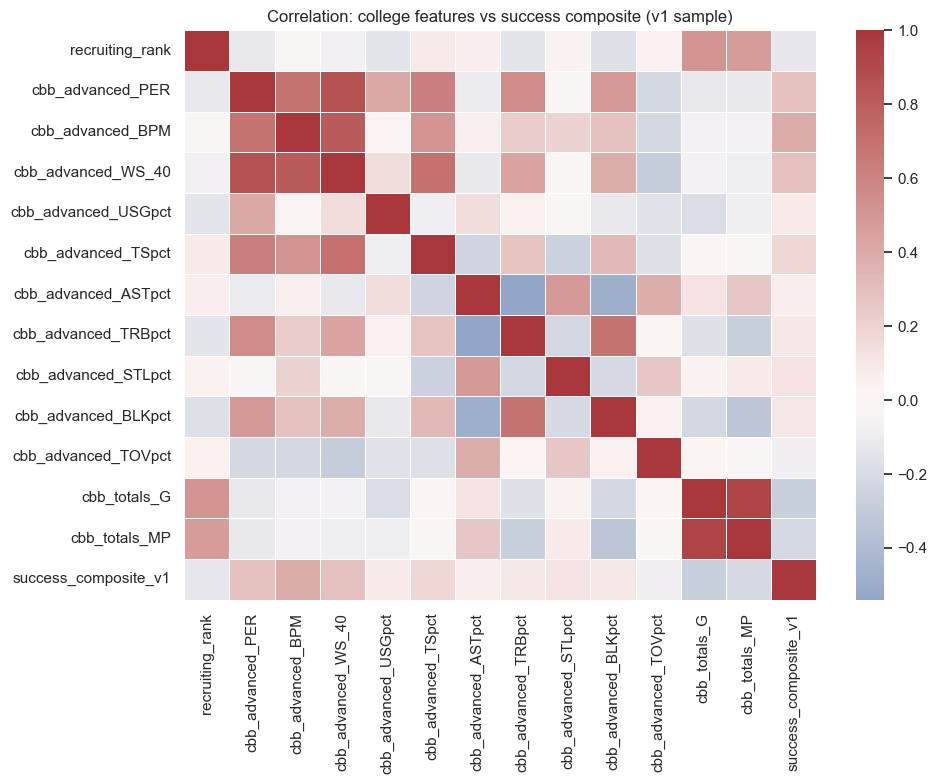

In [3]:
corr_cols = [c for c in FEATURE_COLS if c in m.columns and c != "recruiting_year"]
corr_cols = corr_cols + ["success_composite_v1"]
corr_mat = m[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_mat, ax=ax, cmap="vlag", center=0, annot=False, linewidths=0.5)
ax.set_title("Correlation: college features vs success composite (v1 sample)")
fig.tight_layout()
fig.savefig(FIG / "eda_cbb_feature_correlation.png", dpi=150)
plt.show()

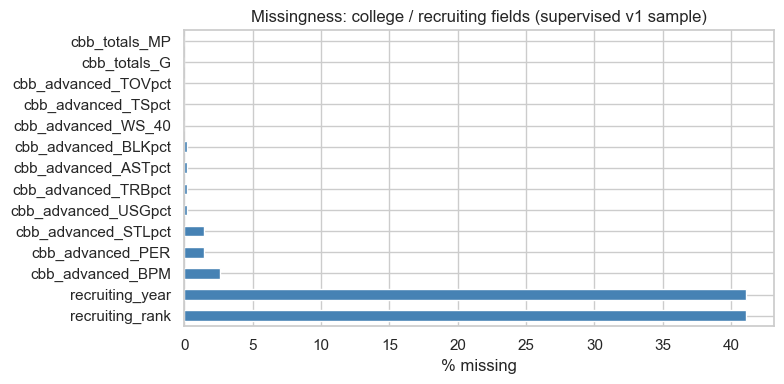

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
miss_pct.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("% missing")
ax.set_title("Missingness: college / recruiting fields (supervised v1 sample)")
fig.tight_layout()
fig.savefig(FIG / "eda_cbb_missingness.png", dpi=150)
plt.show()

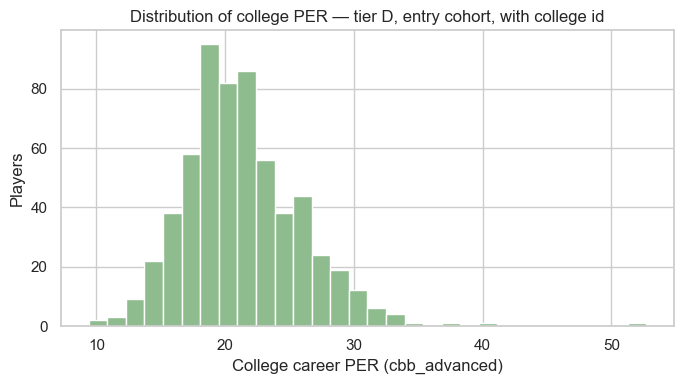

In [5]:
per = m["cbb_advanced_PER"].dropna()
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(per, bins=30, color="darkseagreen", edgecolor="white")
ax.set_xlabel("College career PER (cbb_advanced)")
ax.set_ylabel("Players")
ax.set_title("Distribution of college PER — tier D, entry cohort, with college id")
fig.tight_layout()
fig.savefig(FIG / "eda_cbb_per_distribution.png", dpi=150)
plt.show()

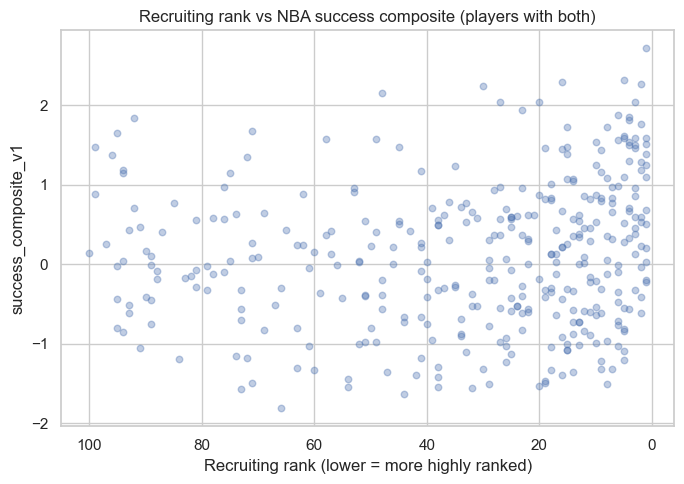

n with both recruiting_rank and composite: 360


In [6]:
sub = m.dropna(subset=["recruiting_rank", "success_composite_v1"]).copy()
fig, ax = plt.subplots(figsize=(7, 5))
if len(sub) > 5:
    ax.scatter(sub["recruiting_rank"], sub["success_composite_v1"], alpha=0.35, s=22)
    ax.invert_xaxis()
    ax.set_xlabel("Recruiting rank (lower = more highly ranked)")
    ax.set_ylabel("success_composite_v1")
    ax.set_title("Recruiting rank vs NBA success composite (players with both)")
else:
    ax.text(0.5, 0.5, "Not enough joint non-null recruiting_rank + composite", ha="center")
fig.tight_layout()
fig.savefig(FIG / "eda_cbb_recruit_vs_composite.png", dpi=150)
plt.show()
print("n with both recruiting_rank and composite:", len(sub))